<h2 style="color:#1a5276;">Profiles of Community Health Across U.S. Counties</h2>

**Authors:** Badamgarav Battushig, Edwin Okwor, Sravyasri Murala

**Course:** DATA 5322 - Statistical Machine Learning 2

**Date:** May 31, 2026

---
<h2 style="color:#2874a6;">Introduction</h2>

Public health is not spread evenly across the United States and the patterns aren't always what you'd expect. Two counties on opposite sides of the country can look more like each other than two neighboring counties in the same state. That's not just an interesting observation, it's actually useful if you're trying to design public health programs. A program that worked in one county is more likely to work in another county with a similar health profile, even if they're a thousand miles apart.


We wanted to find those profiles. Using the CDC PLACES 2025 dataset which provides model-based estimates of 40 health measures for every U.S. county we asked a simple question: what natural groupings emerge when each county is treated as a point in 40-dimensional health space?


The CDC PLACES data is built from the Behavioral Risk Factor Surveillance System (BRFSS), the Census Bureau's American Community Survey, and decennial Census data. It covers chronic disease outcomes (like stroke, diabetes, and COPD), preventive care behaviors (like dental visits and cancer screening), disability measures, health status, and also in the 2025 release on health-related social needs like food insecurity and transportation access. We used the CDC PLACES 2025 release, which contains
measures from both 2022 and 2023 BRFSS survey data published in 2025 which covers all 3,144 U.S. counties.


Our analysis pipeline:

1. Matrix completion to fill missing values using low-rank structure
2. PCA/SVD to find the main axes of county health variation
3. K-means clustering to group counties into interpretable profiles
4. Hierarchical clustering to validate those groupings with a different method

---
<h2 style="color:#2874a6;">Data Source</h2>

The data comes from the CDC PLACES 2025 release, freely
available at https://www.cdc.gov/places. It provides
model-based estimates of 40 health measures for every
U.S. county, built from the Behavioral Risk Factor
Surveillance System (BRFSS) surveys conducted in 2022
and 2023.

The dataset we used is hosted on Hugging Face for easy
access: https://huggingface.co/datasets/kembaoak/CDC_Health_Data

The 40 measures span six categories: chronic disease
outcomes, disability, mental health, preventive care
behaviors, risk behaviors, and health-related social
needs. Each measure is reported as the estimated
percentage of adults in that county with that condition
or behavior.

---
<h2 style="color:#2874a6;">Theoretical Background</h2>


<h3 style="color:#148f77;">Unsupervised Machine Learning</h3>

Most machine learning models learn from data that already have known answers. For example, a model can learn to predict which counties will have high disease rates based on labeled training examples. Unsupervised learning works differently. Instead of predicting an outcome, it looks for hidden patterns and relationships within the data itself.

Unlike supervised learning, there are no predefined groupings or correct answers
to guide the algorithm. Instead, the algorithm is left to discover natural
structure and patterns on its own by making it especially useful for exploratory
analysis where the goal is to understand what the data contains rather than
predict a specific outcome.





<h3 style="color:#148f77;">Matrix Completion</h3>

Real world datasets are rarely complete. Matrix completion is a technique
for filling in missing values by assuming the data has low-rank structure
meaning a small number of hidden patterns explain most of the variation
in the data. Rather than replacing missing values with a simple average or median
matrix completion uses the relationships between rows and columns to
estimate plausible values. This preserves the full dataset while making
use of the patterns already present in the observed entries.

In this project, matrix completion is applied to fill missing health
measure values across U.S. counties before any further analysis is performed.

<h2 style="color:#148f77;">Principal Component Analysis(PCA) & Singular Value Decomposition(SVD)</h2>

### Principal Component Analysis

**PCA/SVD** reduces many correlated health measures into a smaller set of components. PCA finds directions of maximum variation, while SVD provides the matrix-decomposition view of the same idea. In this setting:

- The PCA score matrix, or **U matrix** from SVD, tells us where each county falls on the main health-pattern dimensions.
- The PCA loading matrix, or **V\*** matrix from SVD, tells us which health measures define those dimensions.

Imagine trying to compare counties using dozens of health
measures at once, diabetes rates, dental visits, food
insecurity, mobility disability. Looking at all of these
separately is overwhelming. PCA combines them into a smaller
number of new variables that capture the biggest differences
between counties.

Principal Component Analysis (PCA) helps simplify the data by finding the most important patterns. Instead of looking at every variable separately, PCA combines them into a smaller number of new variables called principal components.

You can think of PCA as creating a summary of the data. Rather than needing dozens of measurements to describe a county, we can often capture much of the information using just a few principal components. This makes it easier to visualize and understand the overall structure of the dataset.

### Singular Value Decomposition


SVD is the mathematical engine behind PCA. While PCA focuses on finding the most important directions of variation in a given data, SVD's main job is to calculate those directions.

One way to think about SVD is as a method that is used for breaking a large, complex dataset into smaller pieces that are easier to comprehend. The U matrix shows where each county (observation) sits on each pattern. The diagonal matrix D contains the singular values, whose squares encode how much variance each pattern explains. The V* matrix contains the loadings on how much each health measure contributes to each pattern.




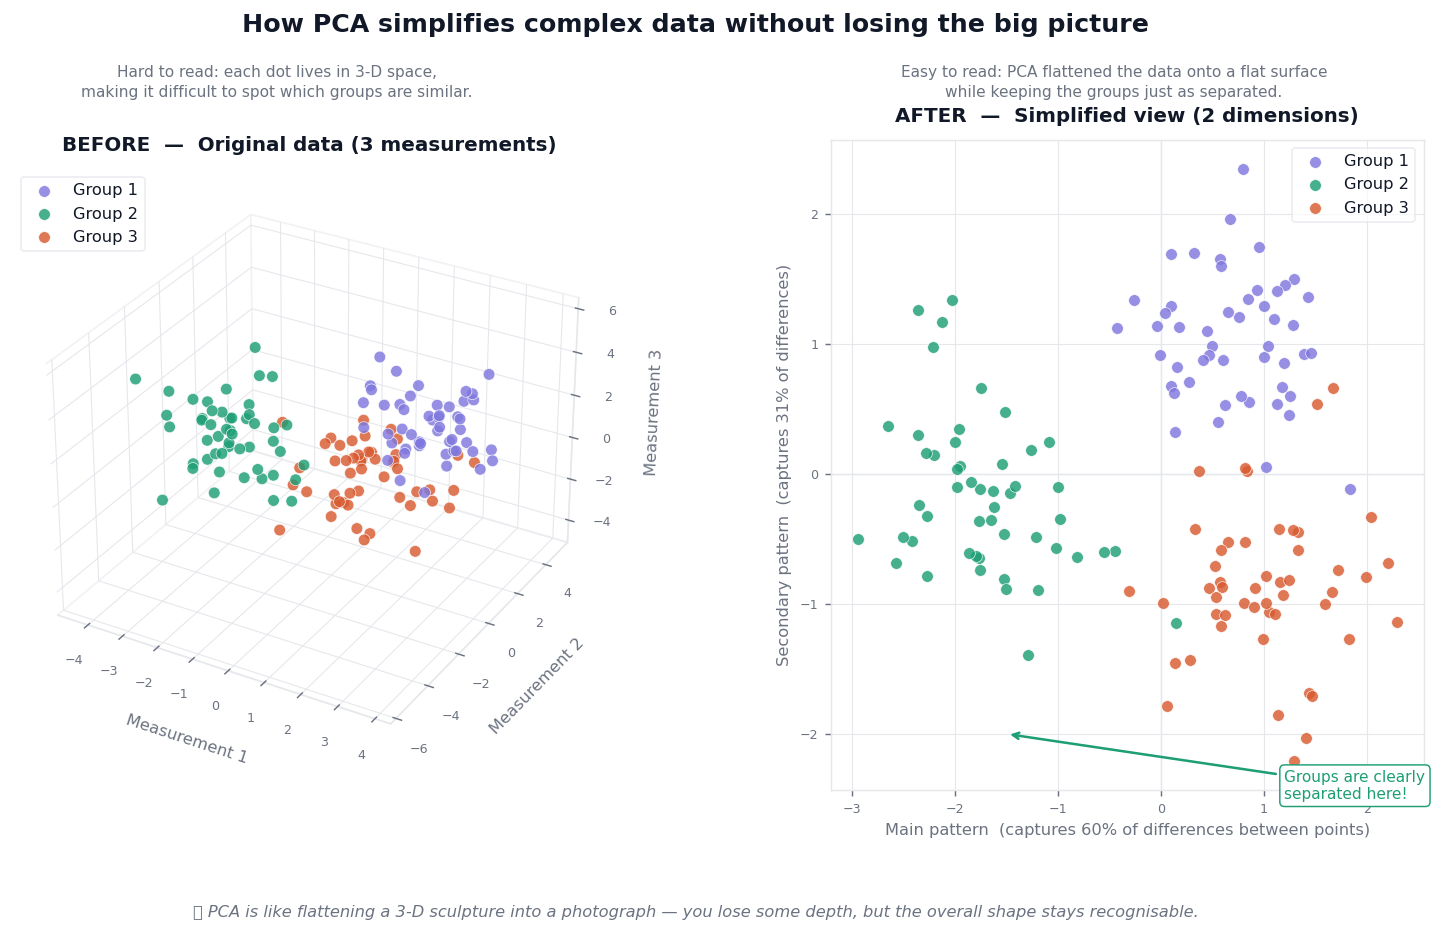


Together, PCA and SVD give us a powerful way to simplify the data. But how
do we know how many components are actually worth keeping? That is where
the scree plot comes in.

### What is a Scree Plot?
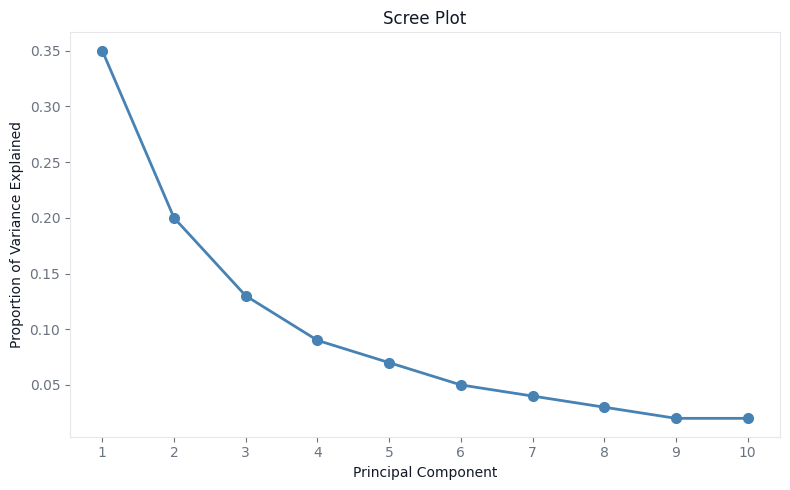



When we run PCA, one of the first things we look at is a **scree plot**. Think of it as a "usefulness ranking" of each new summary
variable PCA creates.

The first principal component always captures the biggest patterns in
the data, the second captures the next biggest, and so on. In the figure above,
you can see that the first component explains 35% of all the variation
in the data, and the second explains another 20%. After that, each
additional component adds less and less new information, and the curve
flattens out.

That drop-off point, where the line bends and flattens is called the
**"elbow."** In the figure, the elbow appears around component 3 or 4.
Everything to the right of the elbow is mostly noise, meaning those
components are not adding much to our understanding of the data.

This tells us something important: even though our dataset may have
dozens of variables, most of the meaningful structure can be captured
in just the first few principal components. That is the whole point of
PCA, simplifying complex data without losing what matters.

<h3 style="color:#148f77;">K-Means Clustering</h3>

**K-means clustering** groups counties by placing each county into the nearest cluster center. It is useful for creating practical county profiles, but it requires choosing the number of clusters.

#### How It Works
1. Choose K starting points using k-means++ initialization, which spreads initial centroids to reduce sensitivity to starting positions
2. Assign every data point to its nearest centroid
3. Recalculate each centroid as the average of all points assigned to it
4. Repeat steps 2–3 until assignments stop changing

Note: A centroid is basically the center of a cluster in clustering algorithms like k-means.

The Math Underneath: The algorithm minimizes within-cluster variance as it ensures that each cluster is as tight and compact as possible.



#### K-Means Clustering Illustrated

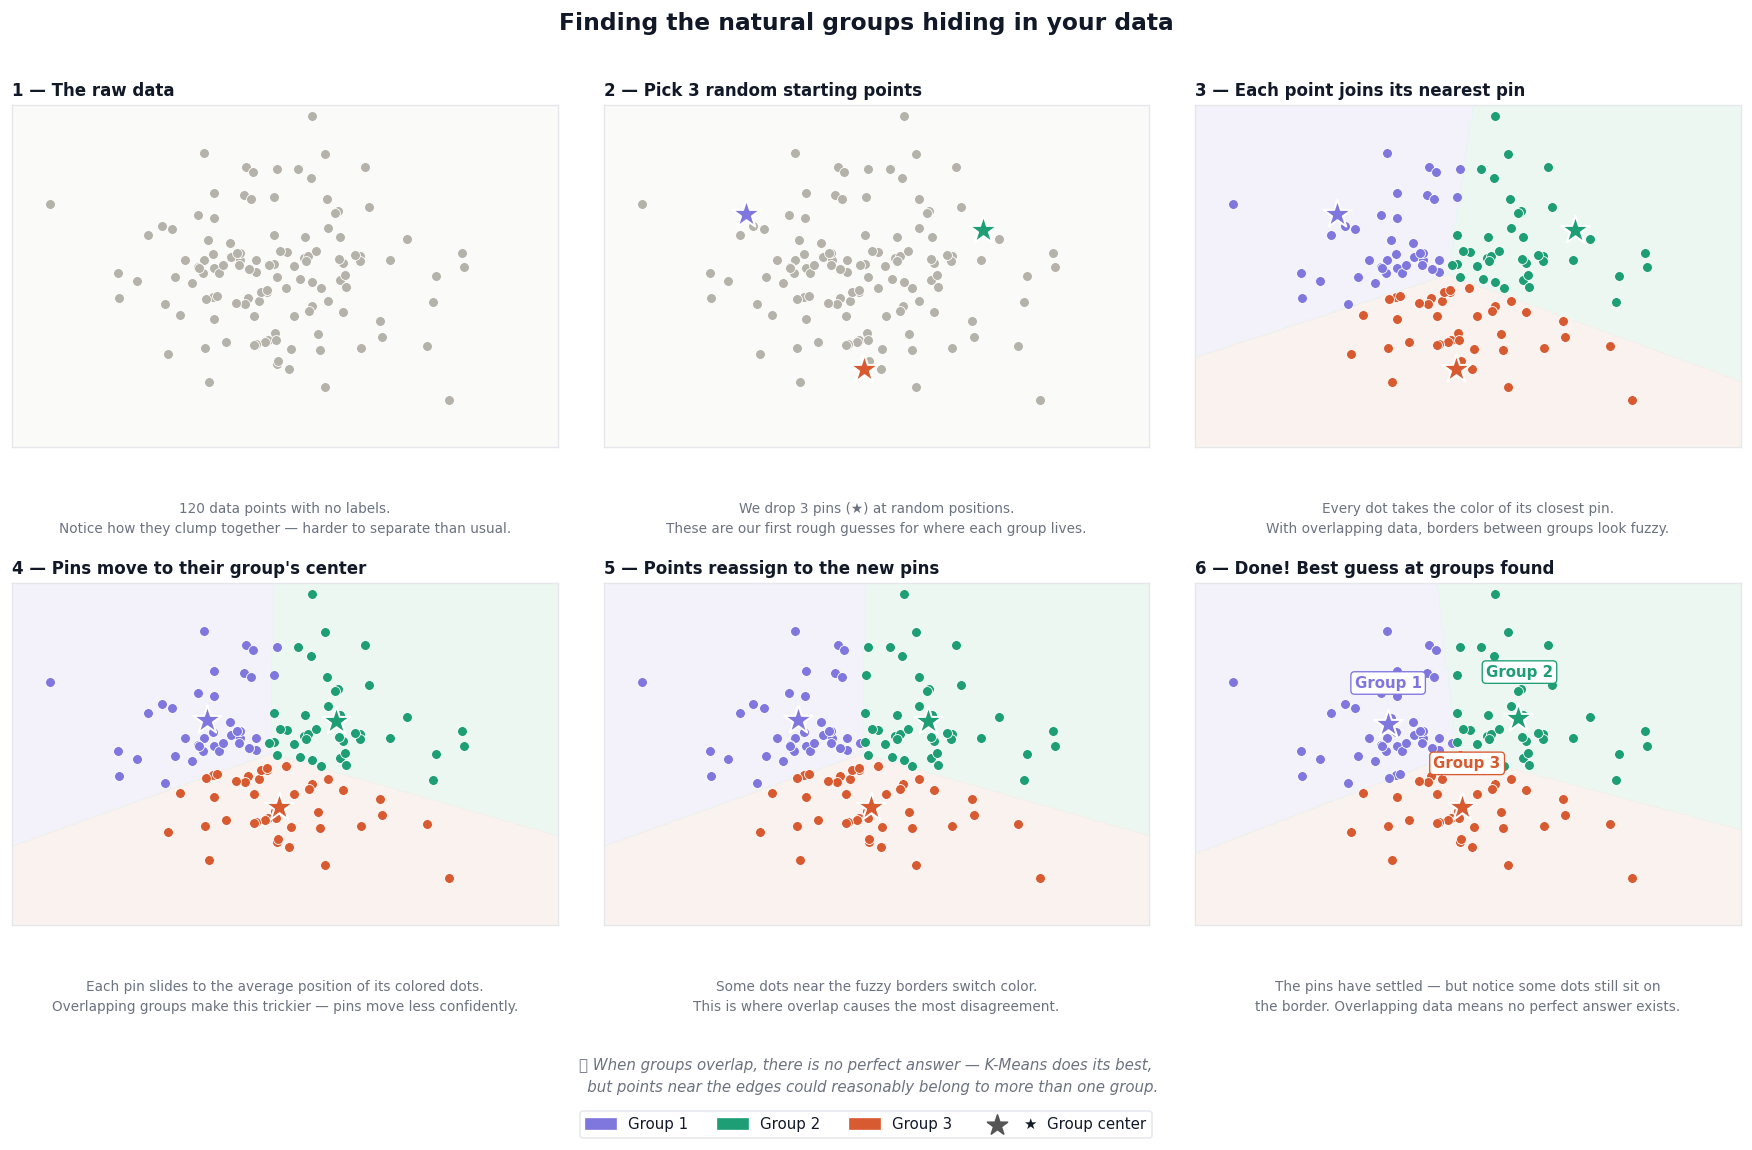

<h3 style="color:#148f77;">Hierarchical Clustering</h3>

Hierarchical clustering works different from k-means, instead of forcing the data into a fixed number of groups upfront, it gradually builds a "family tree" of clusters that shows how similar everything is at different levels. There are two main types of hierarchical clustering:

1. Agglomerative Clustering(Bottom-Up Approach)

This is the most common method.

- You start with every data point as its own group
(so if you have 100 points, you begin with 100 tiny clusters)
- Then, step by step, you merge the two most similar clusters
- You keep merging until everything becomes one big cluster

At the end, you can visualize the process using something called a dendrogram, which looks like a tree and shows how clusters were formed and connected.


2. Divisive Clustering(Top-Down Approach)

This one works the opposite way:

- You start with all points in a big cluster
- Then you keep splitting it into smaller groups
- You continue until each data point is its own cluster

This approach is less commonly used because it usually takes more computing power and is more complex.


#### A simple way to think about Agglomerative Clustering

Agglomerative clustering can sound complicated, but the basic idea is something many of us do naturally.

Imagine you have a large box of old family photos scattered across a table. You start sorting them by finding pictures of the same person and placing them together. Next, you group siblings into larger piles, then combine those piles with photos of cousins. As you continue, more distant relatives get connected until eventually every photo belongs to one large family tree.

Agglomerative clustering works in much the same way. It starts with every data point in its own group and gradually combines the most similar groups together. The closest matches join first, while less similar groups are connected later. By the end, all of the data points are linked together in a hierarchy that shows how the clusters were formed.


#### The algorithm works the same way:
The idea behind hierarchical clustering is surprisingly simple. First, every data point starts out on its own. If you have 100 data points, you begin with 100 separate clusters.

Next, the algorithm measures how similar the clusters are. This is usually done using distance measures such as Euclidean distance, Manhattan distance, or cosine similarity.

Once the similarities are calculated, the algorithm finds the two closest clusters and merges them together. It then repeats the process, continually combining the most similar groups.

Eventually, all of the data points become part of one large cluster. Along the way, the algorithm creates a tree-like structure called a dendrogram, which helps visualize how the clusters were formed.



### The Dendrogram

The result is a tree diagram called a **dendrogram**. While clustering algorithms like K-Means simply tell us which group a data point belongs to, a dendrogram goes a step further by showing how all the data points are related to one another.

A dendrogram is a tree-like diagram that visualizes the clustering process. The data points are shown along the bottom, while the vertical axis represents the distance or dissimilarity between clusters. As you move upward through the tree, smaller clusters merge into larger ones. As you move downward, larger Clusters split into more detailed groups.

One way to think about dendogram is as a family tree. Close relatives are connected near the bottom because they are very similar, while distant relatives only connect higher up in the tree. Eventually, everything traces back to a single root, representing the entire dataset.

What makes dendrograms especially useful is that they allow us to choose the number of clusters after the clustering process has been completed. Instead of deciding beforehand how many groups we want, we can draw a horizontal line across the dendrogram. Every branch that intersects that line becomes its own cluster.

The height of the cut determines the level of detail we see. A cut near the bottom creates many small clusters, while a cut higher up creates fewer, larger clusters. This flexibility is one of the biggest advantages of hierarchical clustering because it lets us explore our data at different levels of granularity rather than committing to a single clustering solution from the start.

In short, a dendrogram is more than just a visualization. It tells the story of how clusters were formed, reveals the relationships between data points, and helps us decide where meaningful groups naturally exist in the data.




### Hierarchical Clustering Explained With Animals (and Pretty Charts)

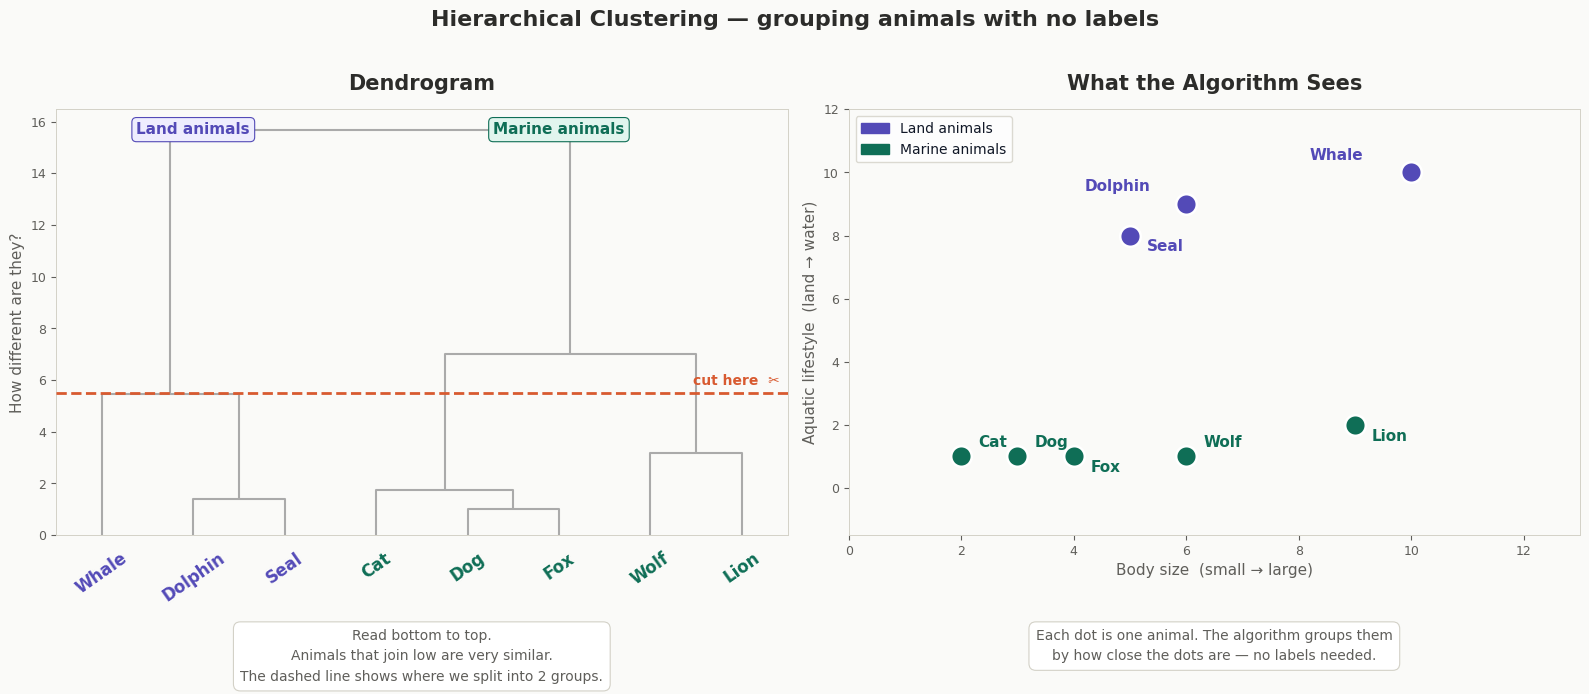


#### Where to Cut the Dendrogram

The decision on where to slice the dendrogram can either be decided visually
or even with the opinion that you desire to have a minimum distance of 'y'
(the location of cut in the y-axis) between clusters.

**Cutting high**: draws the line near the top of the tree, resulting in
fewer but broader clusters. In the animal example, cutting high would group
everything into just one big group.

**Cutting low**: draws the line near the bottom of the tree, resulting in
many small clusters. Cutting too low would put every single animal in
its own group, which is not very useful.

**Cutting in the middle**: this is where the natural boundary lives.
Look for the longest vertical line that no horizontal line crosses.
That gap is where the data naturally separates. In the animal example,
that gap falls between the land animals and the marine animals —
the two groups the algorithm discovered on its own.

A simple rule to remember:

> The longer the vertical line, the more different those two groups are.
> Cut through the longest gap and the number of branches below the line
> is the number of clusters.


#### How Similarity Is Measured

When clusters contain multiple points, you need a rule for how to measure distance between them. That rule is called linkage and there are 4 types of linkage:

- **Single linkage** - compares the two closest points across groups.
  Risk: groups can chain together in long, winding strings.
- **Complete linkage** - compares the two farthest points across groups.
  Risk: a single outlier can distort results.
- **Average linkage** - takes the average distance across all point pairs.
  A reasonable middle ground.
- **Ward's method** - merges groups that keep the overall clusters as
  tight as possible. Tends to produce clean, balanced, easy-to-interpret
  groups. The most recommended option for most situations.


<h2 style="color:#2874a6;">Methodology</h2>

The raw CDC PLACES data came in a format where each row
was one county-measure combination basically a very long
list. We reshaped it into a table where each row is one
county and each column is one health measure, giving us
3,144 counties and 40 measures to work with.



<h3 style="color:#148f77;">Data Cleaning</h3>

| Item | Value |
|------|-------|
| Counties | 3,144 |
| Health measures | 40 |
| Missing entries | 11,144 |
| Missing percent | 8.86% |

About 9% of the table was empty. Most of that missingness
came from two places Kentucky and Pennsylvania counties
were missing almost all of their measures because those
states didn't collect enough survey data in 2023, and 11
states didn't report the social needs measures at all. We didn't drop those counties or those measures. Dropping
them would have removed entire states from the analysis
and biased the results toward larger urban areas. Instead
we filled in the missing values using a method called
matrix completion, which uses the patterns already present
in the data to estimate what the missing values likely
were rather than just replacing them with a national
average.

Before running any analysis, we scaled every health
measure to the same range. This matters because some
measures vary a lot across counties and others barely
change for example, dental visit rates swing widely
from county to county, while stroke rates stay in a
much narrower band. Without this scaling step, the
measures that happen to vary the most would drown out
everything else, and the results would reflect that
noise rather than actual health patterns.

### Figure 1. Missingness in the county health matrix

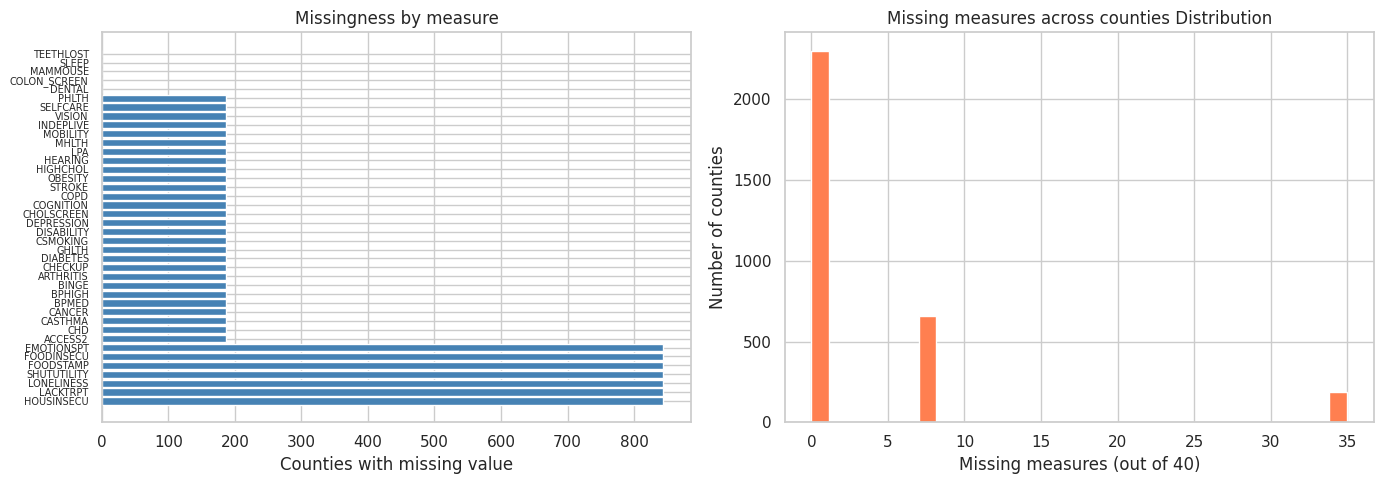

*Missingness is concentrated in a subset of measures, which motivates matrix completion instead of dropping variables.*

To find the best setting for our matrix completion method, we temporarily hid 10% of the known values, filled them in using different settings, and measured how close the filled values were to the real ones. The best setting produced an average error of about 0.41 percentage points in standardized units, meaning the method was recovering missing health measure values quite accurately.

### Figure 2. Matrix completion rank tuning

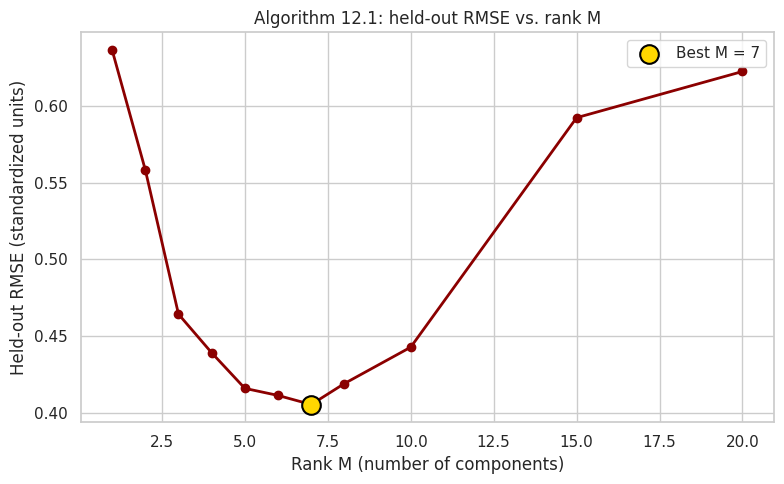

*Error drops as we increase complexity, then rises
again, the sweet spot is in the middle.*

We also compared our matrix completion method against
simpler baseline approaches.

| Method | Prediction error (lower is better) |
|---|---:|
| Mean | 1.0037 |
| Median | 1.0147 |
| k-NN, k = 5 | 0.3386 |
| Matrix completion (our method), M = 7 | 0.4056 |

The k-nearest neighbor method had the lowest prediction
error, but our matrix completion approach was kept because it fills missing entries using a low-rank SVD approximation, making the completed matrix directly consistent with the low-rank structure PCA assumes. k-NN imputation has no such theoretical connection to SVD.

### Figure 3. Imputation method comparison

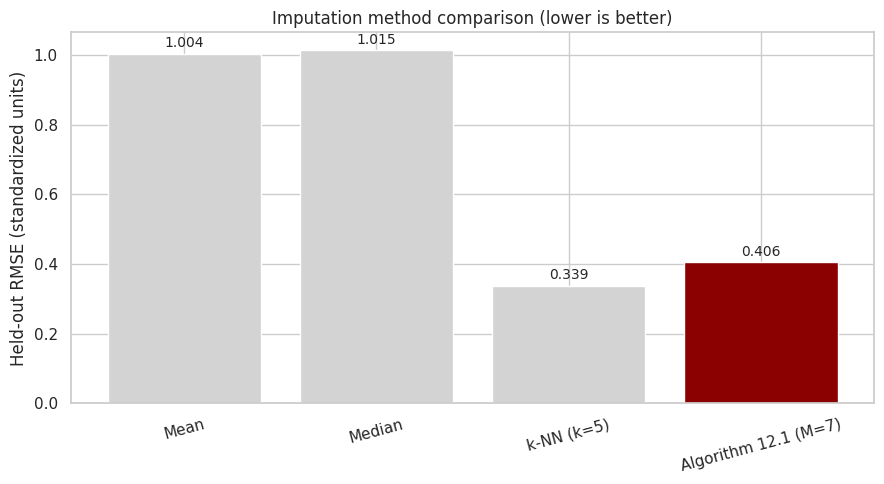

*Lower bar means better recovery of missing values.*

We kept the first 6 components from PCA, which together
explain about 90% of the variation, and used those as
the input for clustering instead of all 40 raw measures.
For k-means we ran the algorithm 20 times with different
starting points and kept the best result. For
hierarchical clustering we cut the tree at 4 groups to
match k-means, making the comparison direct. To
interpret each cluster we compared its average health
measures to the national county average. All analysis
was done in Python.

<h2 style="color:#2874a6;">Results: PCA and SVD</h2>

Running PCA on the completed matrix showed that the 40
health measures are far from independent. Most of the
differences between counties can be captured by just
a handful of dimensions.

| Component | Individual variance | Cumulative variance |
|---|---:|---:|
| PC1 | 60.4% | 60.4% |
| PC2 | 12.1% | 72.4% |
| PC3 | 9.8% | 82.2% |
| PC4 | 3.8% | 86.1% |
| PC5 | 3.1% | 89.2% |
| PC6 | 2.1% | 91.2% |

Only **3 components** were needed to explain at least 80% of the variation, and **6 components** explained about 90%.

### Figure 4. Scree plot and cumulative variance explained

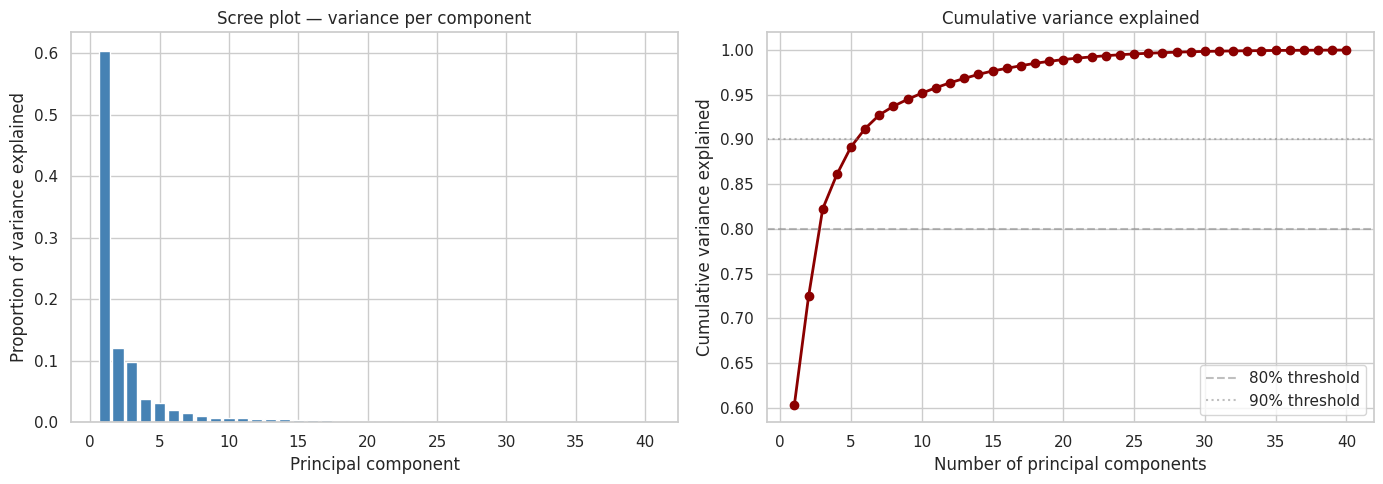

The first component capturing 60% on its own means the 40
health measures are not really 40 independent things that they
mostly reflect one underlying gradient of overall health
burden. The sharp drop from the first to the second component
and the flat tail after the third means the data has a
dominant structure. If the curve were flat, no single
dimension would matter more than another and there would be
no meaningful structure to find.

This is the signature of a low-rank data structure which is the true "information" in the dataset lives in a much lower-dimensional space than the 40 original variables would suggest. In practical terms, this means matrix completion which assumes a low-rank structure and is an appropriate imputation strategy for this data. Many measures move together, so counties can be described by a smaller number of broad health profile dimensions.


<h3 style="color:#148f77;">Interpreting the U and V* Matrices</h3>


The math behind PCA gives us two useful things to look at.

The first is the loading matrix, it tells us which
health measures define each component. Looking at the
first component, mobility disability, poor general
health, self-care disability, stroke, and coronary
heart disease all contribute almost equally with
weights around 0.19 to 0.20. That near-equal weighting
tells us these measures are so correlated that the
first component picks them all up together. Counties
that have high stroke also tend to have high disability
and poor general health. On the opposite end, dental
visits and cancer screening pull in the negative
direction, meaning counties with high disease burden
tend to have lower preventive care access. The second
component separates counties where cancer and
depression are elevated from counties where lack of
health insurance is the bigger issue. That is a completely
different pattern from the burden axis.


### Figure 5. PCA loading patterns

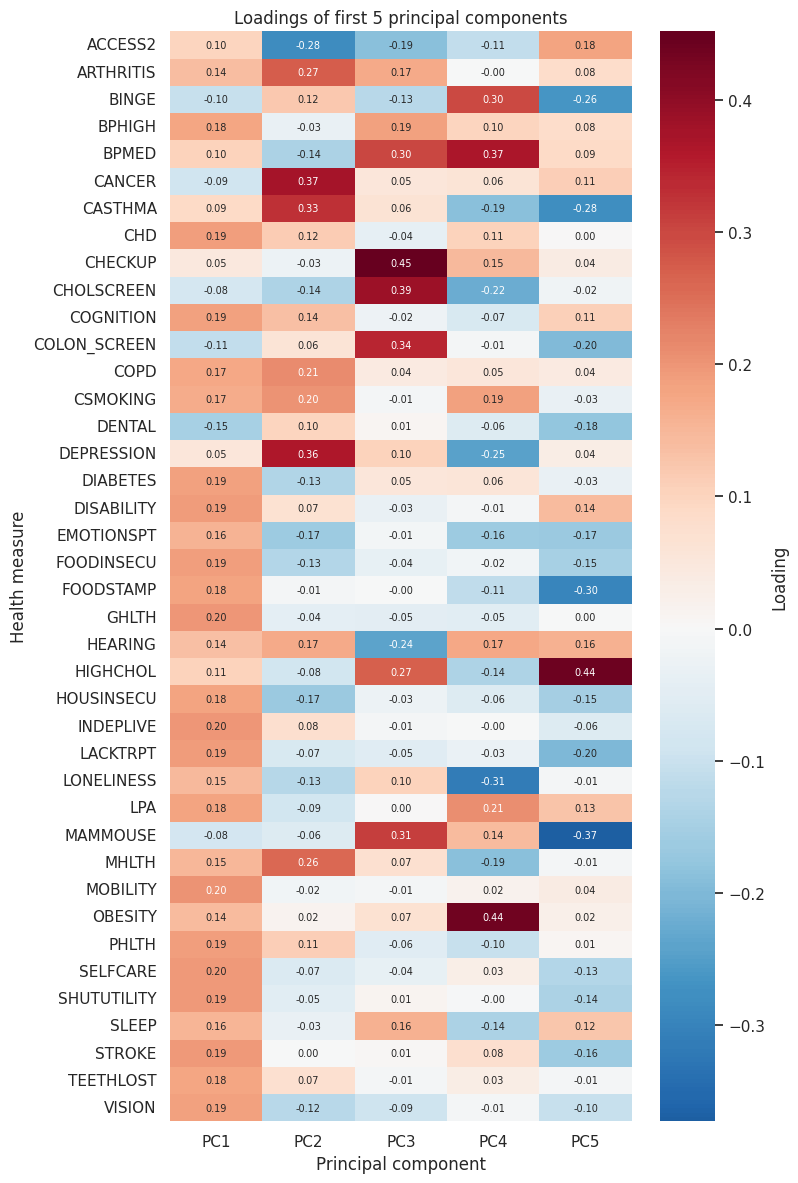

*Each row is a health measure, each column is a component.
Red means that measure pulls in the positive direction,
blue means the opposite.*

PC1 is almost entirely red on the disease and disability
side, that is what makes it readable as one single health
burden axis. The second thing PCA gives us is the score
matrix, which tells us where each specific county falls
on those dimensions. A county with a high score on the
first component has high chronic disease and disability
burden combined with low preventive care. Every county
gets a coordinate in this space based on all 40 measures
at once, not just one or two.

<h3 style="color:#148f77;">Counties in the First Two Principal Components</h3>

Plotting counties in the first two principal components gives a broad map of county health profiles. Counties close together in this plot have similar patterns across all 40 measures.

Southern counties separate clearly to the right along the
first component where those counties score high on the overall
burden axis. Midwestern and Northeastern counties cluster
to the left. The raw obesity versus diabetes plot shows a
similar regional pattern but the groups overlap much more
because you are only seeing two of 40 dimensions. The
principal component plot separates counties more clearly
because it uses all 40 measures simultaneously.

### Figure 6. Counties in PC1-PC2 space

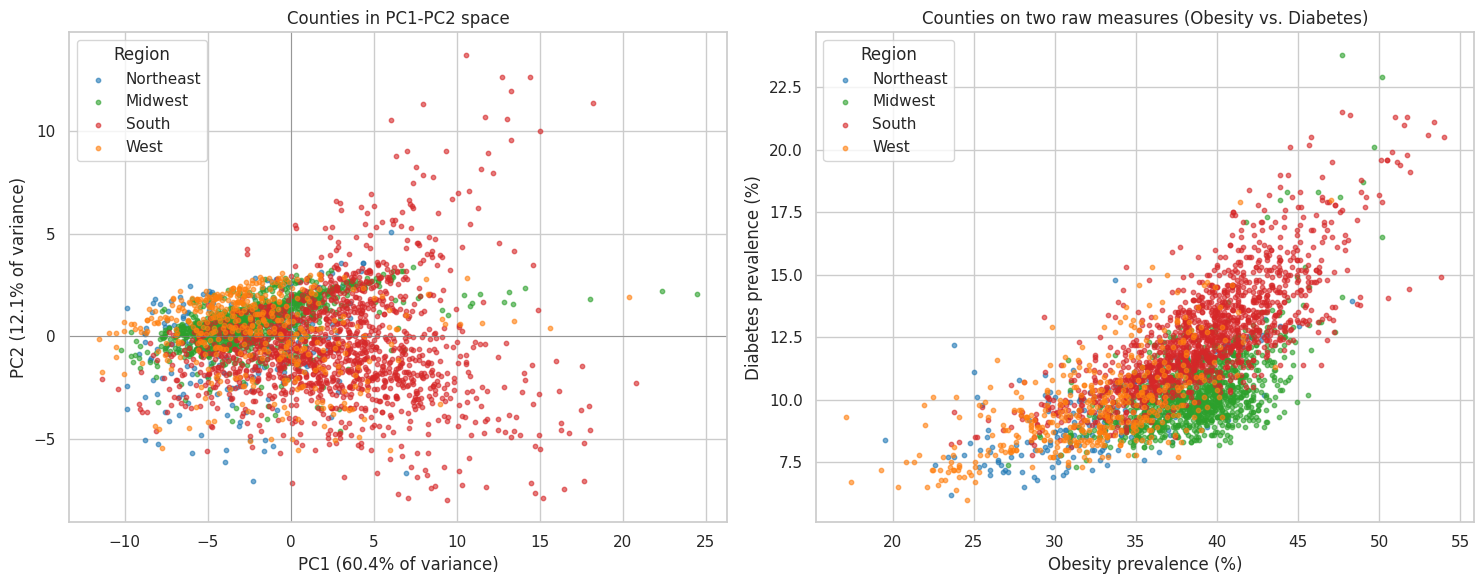

*The PCA view shows broad gradients rather than perfectly separated islands.*

To illustrate what's gained by using PCA, it helps to compare the PC1-PC2 view against a plot using two of the original 40 measures. For example, obesity rate versus diabetes rate. In the original feature plot, counties from different regions overlap considerably. The gradient that separates the Deep South from the Upper Midwest is visible, but many counties cluster in the middle with no clear separation. In the PC1-PC2 view, that same regional gradient sharpens dramatically and counties pull apart along a continuous axis of overall health burden because all 40 measures contribute simultaneously. PCA doesn't create structure that wasn't there which reveals structure that was hidden under the noise of looking at only two dimensions at a time.

### Figure 7. PCA biplot

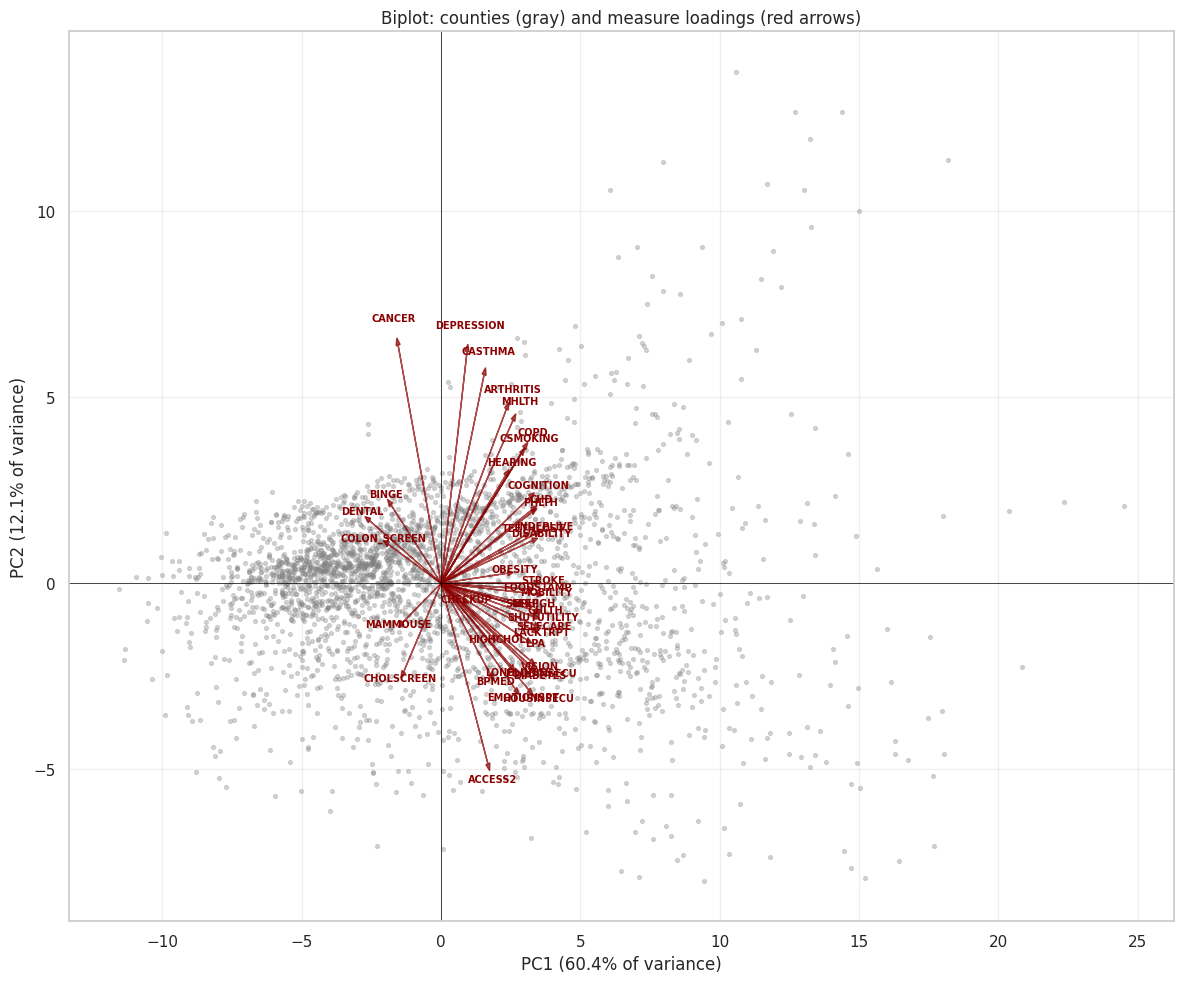

*The biplot shows both counties and measure directions in the first two principal components.*

Most of the disease and disability arrows point right along
the first component like stroke, mobility disability, obesity,
and physical inactivity all bunch together pointing right.
Dental visits, binge drinking, colorectal cancer screening,
and mammography use point left, meaning those go up in
healthier counties. Cancer and depression point more
upward along the second component, meaning they behave
differently from the other disease measures where counties
with high cancer rates aren't necessarily the same counties
with high stroke and disability. Lack of health insurance
points almost straight down, going in its own direction
not perfectly tied to the chronic disease cluster.

---
<h2 style="color:#148f77;">K-Means Clustering</h2>

K-means clustering was applied using the first 6 principal components, which captured about 90% of the variation. The final model used **K = 4** clusters.

The final silhouette score was **0.2192**. This is not extremely high, but that is expected because county health profiles are continuous rather than cleanly separated.

| K-means cluster | Number of counties |
|---|---:|
| 0 | 992 |
| 1 | 1,148 |
| 2 | 751 |
| 3 | 253 |

### Figure 8. K-means tuning
Since K-means requires the number of clusters to be specified before modeling, two methods: the elbow method and the silhouette method were used to determine the optimal number of clusters.

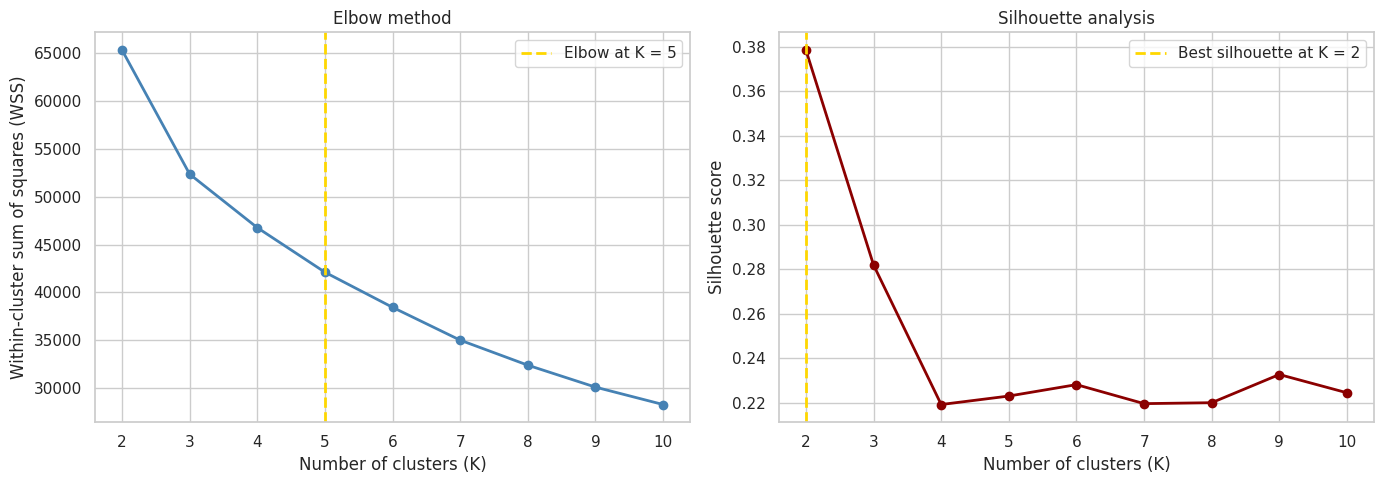

*The elbow and silhouette plots support comparing a small number of interpretable county groups.*

From the plots in Figure 8, the yellow lines indicate the suggested optimal values of K from each method. The elbow method points to K = 5, while the silhouette method peaks at K = 2.

Since these two methods don’t agree, we treated them as complementary rather than definitive. The silhouette score tends to favour more compact, well-separated clusters, while the elbow method focuses on where adding more clusters stops giving meaningful improvement in within-cluster variation.

In this case, we chose K = 4 as a practical compromise. It sits between the two suggestions and aligns with where the elbow curve begins to flatten while still avoiding the overly coarse grouping from K = 2. This choice also produces clusters that are interpretable and meaningfully distinct, without overcomplicating the structure.

### Figure 9. K-means clusters in PCA space

The K-means cluster plot was created using the final choice of K = 4 clusters, based on the balance between the elbow and silhouette methods discussed earlier.

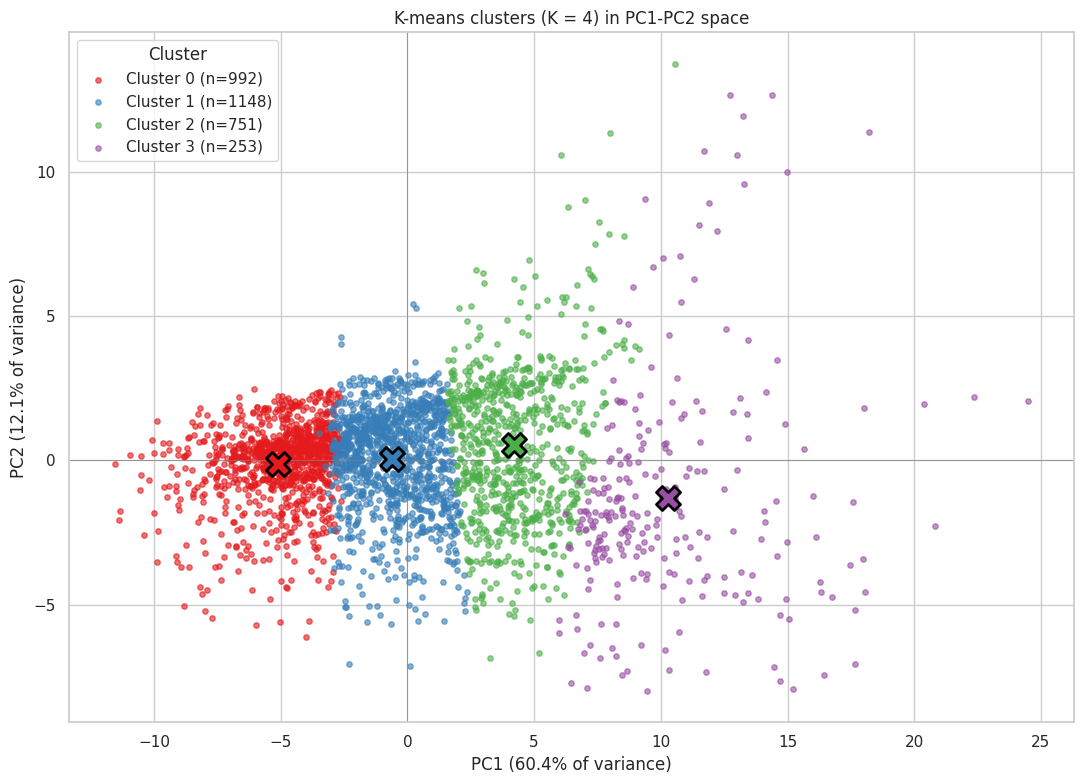

*Counties in the same color have similar health profiles across the first six PCs.*

<h3 style="color:#148f77;">What Do the Clusters Look Like?</h3>

The plot above shows all 3,144 U.S. counties as dots, each coloured by
the group the algorithm placed it in. No one told the algorithm anything
about these counties where it found these groups entirely on its own, which
is pretty cool when you think about it.

The horizontal axis captures over 60% of what makes counties different
from each other across all 40 health measures. We like to think of it
as an overall health score of counties on the right tend to have higher rates of chronic disease and lower access to preventive care, while counties on the left tend to be healthier overall.

Looking at the four groups from left to right:

**Cluster 0**: (red, 992 counties) sits on the far left where these are the healthiest counties, with low chronic disease burden and the highest rates of preventive care like dental visits and cancer screening.

**Cluster 1**: (blue, 1,148 counties) is the largest group, sitting just left of center with broadly average counties, the most common health profile in the U.S.

**Cluster 2**: (green, 751 counties) sits right of center with moderate burden, consistently worse than average on chronic disease and disability measures. the vertical axis that is worth exploring further.

**Cluster 3**: (purple, 253 counties) sits furthest right and is the smallest group of these counties have the worst health outcomes in the dataset, with food insecurity, transportation barriers, and stroke rates all well above the national average, alongside the lowest preventive care access of any group.

One thing we noticed is that the red and blue groups overlap, and so
do the blue and green groups. We do not think this is a flaw as it
actually reflects reality. County health does not switch abruptly
from one profile to another, the transition is gradual, just like
in the real world.

<h3 style="color:#148f77;">Cluster Profile</h3>

A cluster profile was also plotted to help us understand how each group behaves across the different health measures and how they compare to the national average.

### Figure 10. K-means cluster profiles

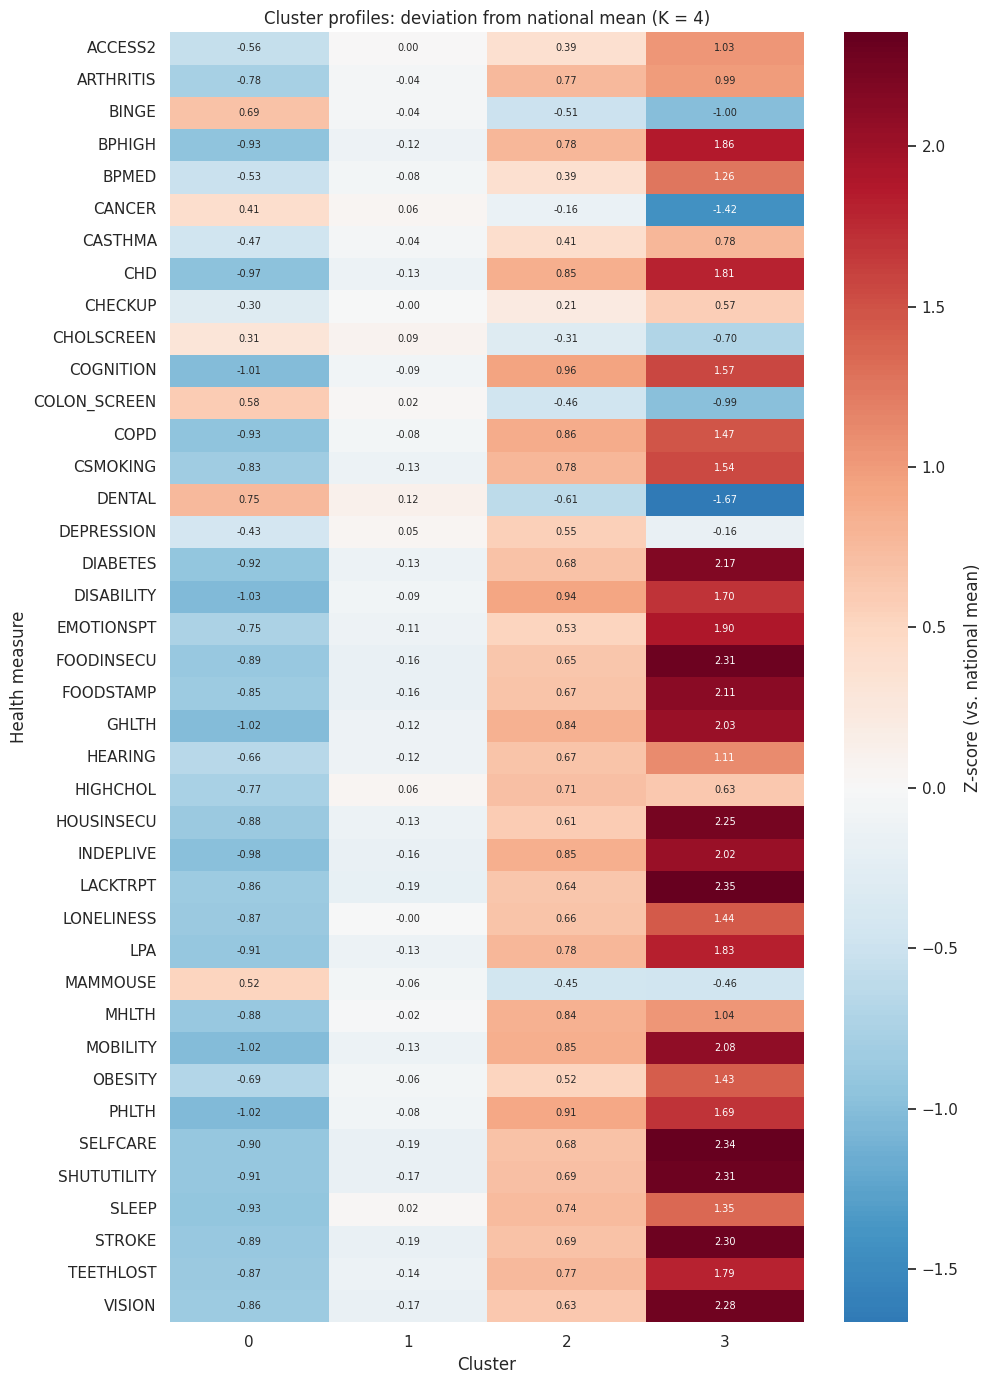

*The heatmap compares each cluster to the national county average across health measures.*

The heatmap above shows how each cluster compares to the national average across all 40 health measures. The values are z-scores: 0 means average, positive values mean above average, and negative values mean below average. Red shows worse-than-average values, while blue shows better-than-average values.

**Cluster 0: The Healthiest Counties**
This cluster is mostly blue across almost every measure. These counties perform better than average on major health outcomes like diabetes, COPD, stroke, and disability. At the same time, they also score higher on preventive care measures such as dental visits, cancer screening, and cholesterol checks. Overall, this is the healthiest group in the dataset.

**Cluster 1: The Average Counties**
This cluster stays mostly white, meaning values are close to zero across the board. These counties sit very close to the national average for nearly all health measures, with no strong positives or negatives. They represent a kind of “baseline” group.

**Cluster 2: The Moderate Burden Counties**
This group shows light red across many indicators. Chronic disease rates, disability, and social risk factors are slightly above average, while preventive care is slightly below average. Nothing is extreme, but the overall pattern shows a consistent, moderate disadvantage compared to the national average.

**Cluster 3: The Highest Burden Counties**
This cluster stands out clearly with the darkest reds in the heatmap. Food insecurity, lack of reliable transportation,
housing insecurity, stroke, vision loss, and self-care
disability are all more than two standard deviations
above the national average. At the same time dental
visits and cancer screening are much lower than average.

What makes this cluster distinct is not just that
these counties are sicker, it's that the worst health
outcomes and the worst access to care are happening
in the same places at the same time. These counties are not only experiencing worse health, but also facing major barriers like food insecurity, housing instability, and transportation issues. These factors are all connected and help explain the overall pattern seen in the data.


<h3 style="color:#148f77;">Where Are These Counties (Figure 11. A visual map)?</h3>

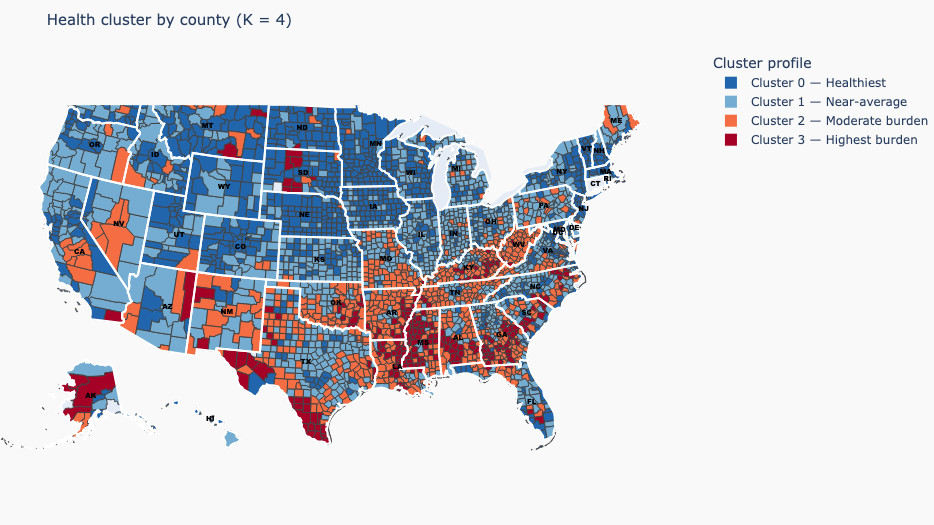

The healthiest group, consisting of 992 counties, is concentrated in the Upper Midwest (northern-central states) and Great Plains(areas known for heavy agriculture), including states such as Nebraska, Minnesota, Iowa, and the Dakotas. These counties are well below the national average on nearly all disease measures and show the highest rates of preventive care, including dental visits and cancer screening.

The largest group, with 1,148 counties, sits close to the national average across most indicators. No single measure strongly deviates in either direction, making these counties broadly representative of typical U.S. health conditions. They are widely distributed across mid-continent states.

A third group of 751 counties, mainly located in the South and Appalachia including Kentucky, Tennessee, Missouri, and Georgia that shows a moderate burden of chronic disease and disability, along with slightly below-average preventive care. While not extreme, the pattern is consistently worse than the national average.

The smallest and most distinct group, containing 253 counties, is concentrated in the Deep South, including Mississippi, Alabama, southern Georgia, and Louisiana. These counties experience very high levels of disadvantage: food insecurity, lack of reliable transportation, utility shutoff threats, and stroke rates are all more than two standard deviations above the national average. At the same time, they have the lowest rates of dental visits and cancer screening of any group.

Overall, this group stands out not just for poor health outcomes, but for the strong overlap between worse health and reduced access to preventive care. This combination distinguishes it from simply being “unhealthy.”

---
<h2 style="color:#148f77;">Hierarchical Clustering</h2>


Hierarchical clustering was applied using the first 6 principal components, which captured about 90% of the total variation. The final model used Ward linkage cut at **K = 4** clusters.

The final silhouette score was **0.1430**. This is lower than k-means (0.2192), but that does not mean the clustering is worse. Ward linkage optimizes within-cluster variance rather than silhouette, and produces far more balanced groups than any other linkage method, as shown in the tuning step below.

| Hierarchical cluster | Number of counties |
|:--------------------:|:------------------:|
| 1 | 574 |
| 2 | 1,138 |
| 3 | 286 |
| 4 | 1,146 |



### Figure 12. Linkage Method Comparison and Dendrograms

Since hierarchical clustering does not require the number of clusters to be specified before modeling, two decisions must be made: the linkage method and where to cut the dendrogram. Four linkage methods were compared to determine the best approach.

<img src="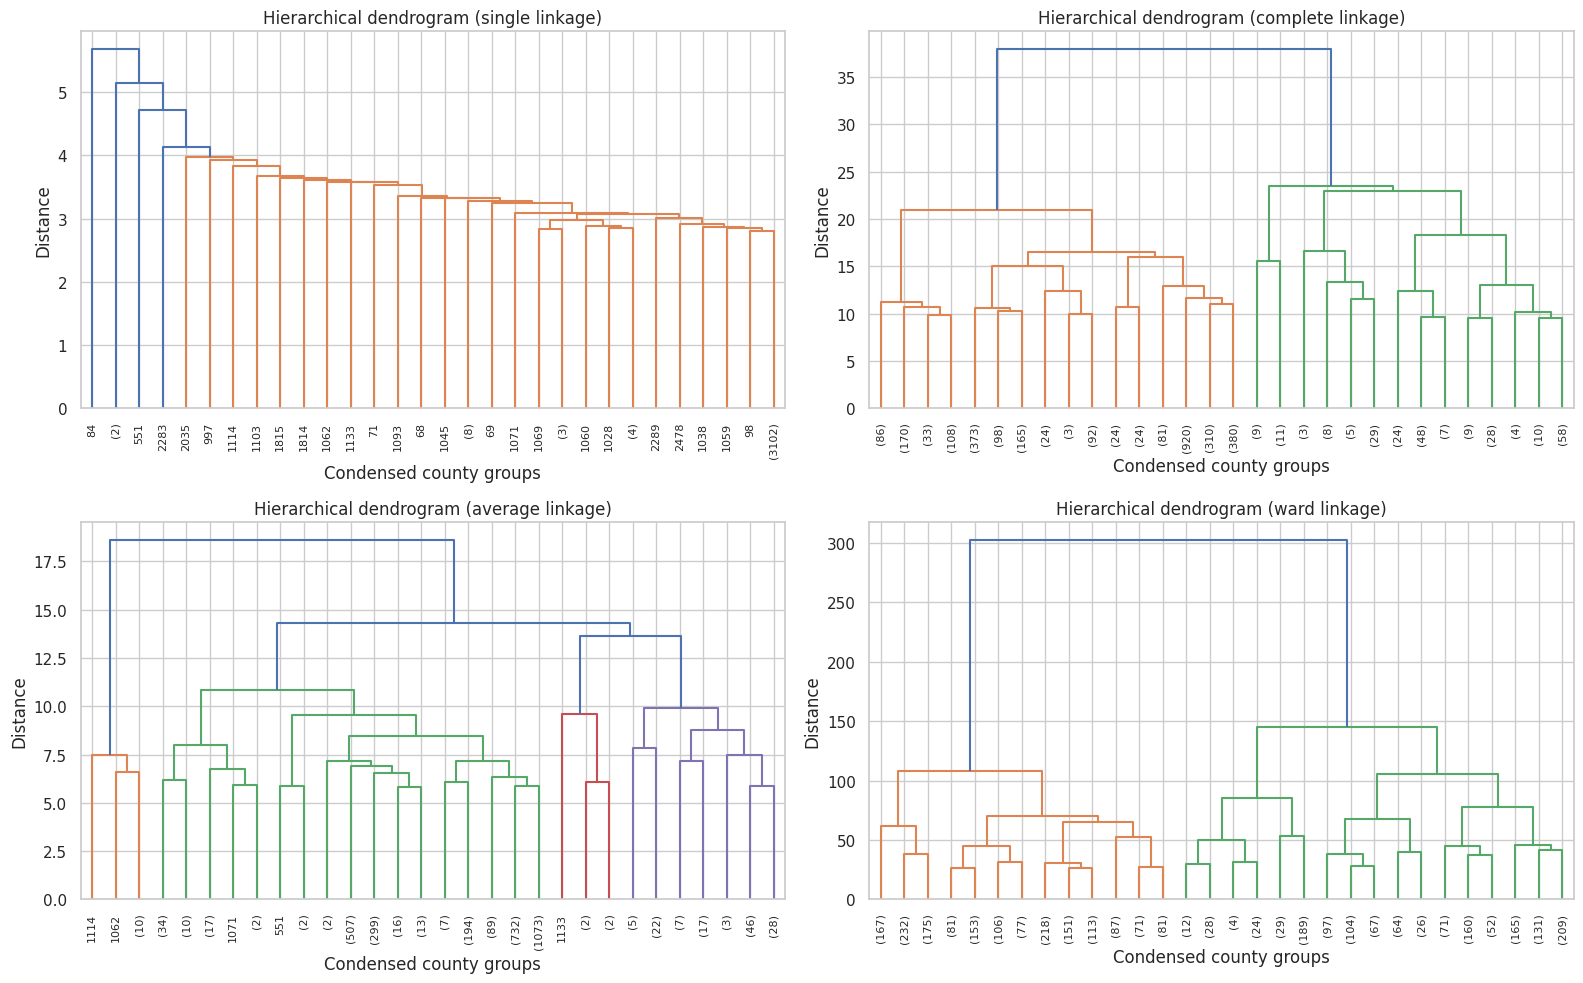
" style="max-width:100%; height:auto;">

*The dendrogram plots support choosing Ward linkage as the only method that produces balanced, interpretable cluster sizes.*

From the dendrograms above, three of the four methods produced degenerate solutions where almost all 3,144 counties collapse into a single branch:

| Linkage | Silhouette score | ARI vs K-means | Smallest cluster | Largest cluster |
|:-------:|:----------------:|:--------------:|:----------------:|:---------------:|
| average | 0.460 | 0.066 | 5 | 2,999 |
| complete | 0.372 | 0.099 | 20 | 2,891 |
| single | 0.248 | 0.001 | 1 | 3,140 |
| **ward** | **0.143** | **0.453** | **286** | **1,146** |


**Single linkage** (top left) shows clear chaining: one branch grows by absorbing individual counties one at a time.

**Complete linkage** (top right) still yields one cluster of 2,891 counties.

**Average linkage** has the highest silhouette score, but it is not actually the most useful result here. It puts 2,999 of the 3,144 counties into one huge group, so the score looks better than the clustering really is.

**Ward linkage** made the most sense for this project because it created four more balanced groups. The dendrogram also shows clearer separation at the cut height. So instead of choosing the method with the highest silhouette score only, we chose the method that gave clusters we could actually interpret.

### Figure 13. Hierarchical Clusters in PCA Space

The hierarchical cluster plot was created using the final choice of Ward linkage cut at K = 4, based on the balance analysis discussed above.

<img src="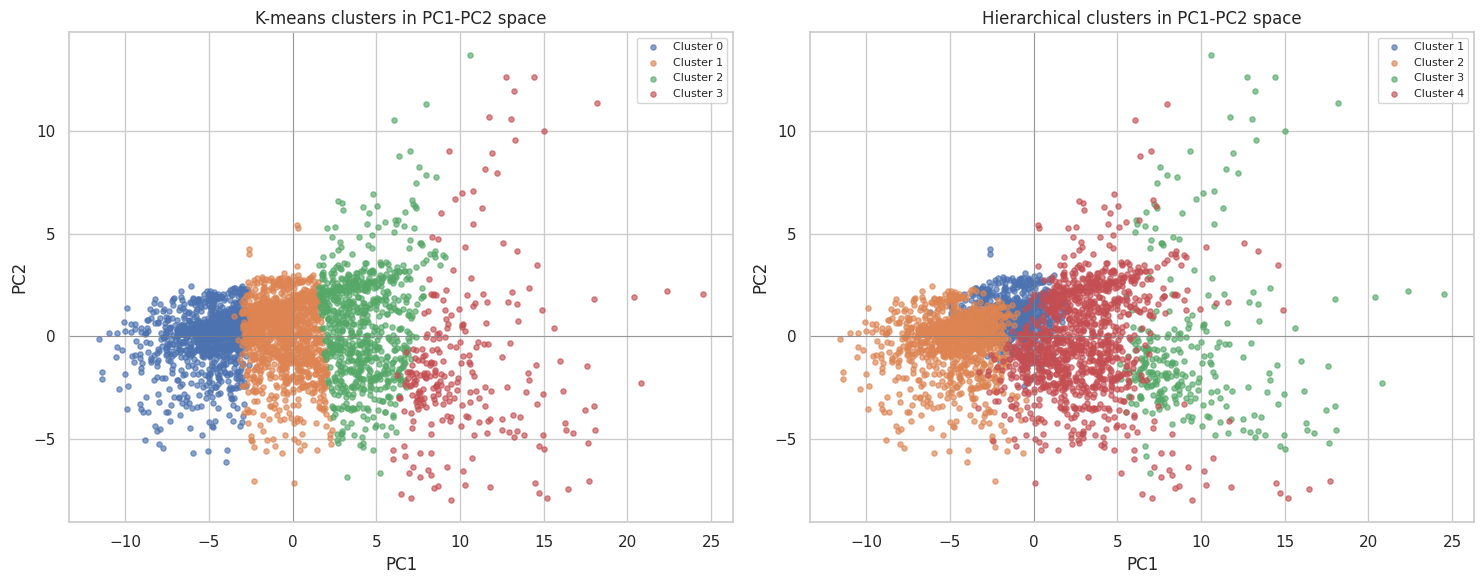
" style="max-width:100%; height:auto;">

*Counties in the same color have similar health profiles across the first six principal components.*

The right panel above shows the hierarchical result. The four clusters form a gradient from left to right along PC1 (60.4% of variance), which represents the health burden axis. Cluster 2 (orange) sits tightly on the left, the healthiest counties. Cluster 3 (green) extends into the far right, the most deprived. Cluster 4 (red) fills the center-right, and Cluster 1 (blue) appears near the center, drifting slightly upward along PC2 (12.1% of variance), consistent with its elevated cancer and depression profile.

Both methods produce a similar visual structure. The main difference is in the middle: K-means creates cleaner horizontal bands across PC1, while hierarchical clustering separates one group more strongly along the PC2 axis. This may happen because Ward linkage uses within-cluster variance across the first 6 PCs, not just the first two shown in the plot.

<h3 style="color:#148f77;">What Do the Clusters Look Like?</h3>

**Cluster 1** (blue, 574 counties) sits near the center but slightly higher along PC2. These counties are not the worst on physical disease. Obesity, diabetes, and stroke are actually below the national average here. But cancer and depression are notably elevated. This group separates from the others mainly along PC2, which is why it appears offset upward in the scatter plot rather than pushed far right.

**Cluster 2** (orange, 1,138 counties) sits on the far left. These are the healthiest counties in the dataset, well below the national average on virtually every chronic disease and disability measure, and well above average on preventive care. High dental visit rates, mammography, colon screening, and cholesterol screening define this group. These counties share not just good health outcomes but strong access to care, which likely drives those outcomes.


**Cluster 3** (green, 286 counties) sits furthest right and is by far the most extreme. Every major chronic disease measure is well above the national average, and the social needs indicators, including lack of transportation, food insecurity, and utility threats, are the highest in the entire dataset. These counties are not just sicker; they face structural barriers that make it harder to access any care at all. The transition from Cluster 4 to Cluster 3 is a genuine discontinuity at the right tail of the health distribution.

**Cluster 4** (red, 1,146 counties) is the largest group and sits right of center. This is the most common health profile in America, mildly elevated on chronic disease measures like diabetes, hypertension, and obesity, with slightly below-average preventive care. No single measure is at an extreme, but the pattern is consistently worse than average across the board. This is the baseline group.

### Figure 14. Hierarchical Cluster Profiles

<img src="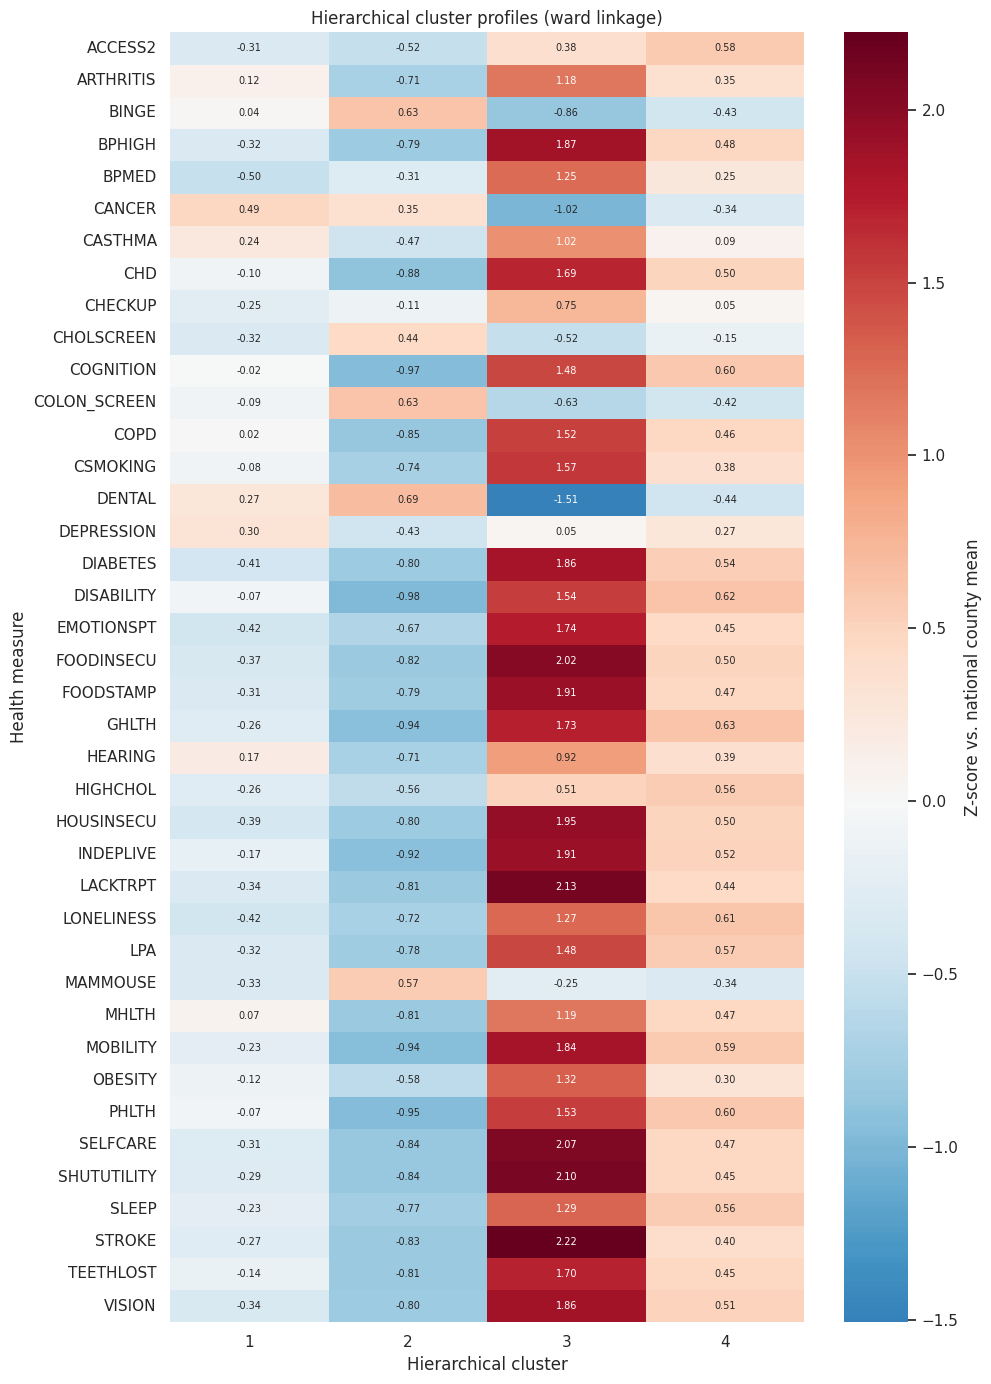
" style="max-width:100%; height:auto;">

*The heatmap compares each hierarchical cluster to the national county average across all 40 health measures.*


The values are z-scores: 0 means average, positive
values mean above average, and negative values mean
below average. Red shows worse-than-average values,
while blue shows better-than-average values.

**Cluster 1: The Cancer and Depression Counties**

This cluster has the most nuanced profile. Diabetes,
COPD, and stroke rates are all close to or below the
national average. But cancer, depression, and asthma
rates are elevated, while emotional support and
loneliness measures are below average. This is a
different kind of health burden with more mental health
and cancer related than chronic disease and disability.

**Cluster 2: The Healthiest Counties**

This cluster is almost entirely blue across every
disease and disability measure. Stroke, disability,
COPD, and poor general health are all well below the
national average. At the same time dental visits,
cancer screening, and mammography use are among the
highest of any group. Binge drinking is also slightly
elevated here, which tends to reflect lower poverty
and greater social activity rather than higher health
risk. This is the healthiest group in the dataset.

**Cluster 3: The Highest Burden Counties**

This cluster stands out with the darkest reds across
the entire heatmap. Stroke rates, lack of reliable
transportation, utility shutoff threats, self-care
disability, food insecurity, housing insecurity, and
diabetes are all roughly two standard deviations above
the national average meaning these counties are
dramatically worse than typical on almost every measure
at once. At the same time dental visits and cancer
screening are severely below average.

**Cluster 4: The Moderate Burden Counties**

This cluster sits close to zero on most measures but
shows mild red on chronic disease. Diabetes, disability,
coronary heart disease, and poor general health are
slightly above average. Dental visits, colon screening,
and mammography are slightly below average. These
counties aren't at an extreme but are consistently
worse than average across the board.

The key insight from Cluster 3 is that the worst health
outcomes and the worst access to care are happening in
the same counties at the same time. Food insecurity,
transportation gaps, and housing instability make it
harder to get care, which compounds the disease burden
and helps explain why outcomes here are so extreme
compared to the rest of the country.

### Figure 15. Cluster Size Comparison: K-Means vs. Hierarchical

<img src="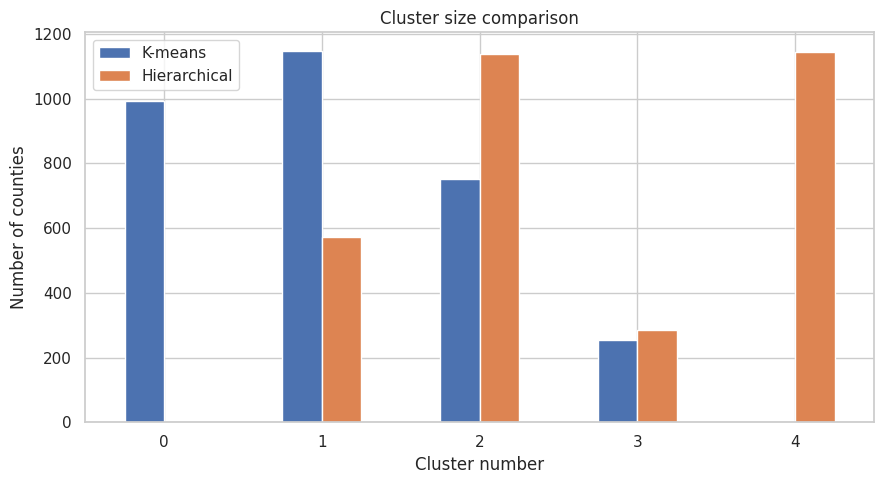
" style="max-width:100%; height:auto;">

*The size comparison checks whether the methods create interpretable groups instead of one giant group and many tiny groups.*

The bar chart confirms that both k-means and hierarchical clustering produce four groups of roughly comparable scale. The smallest cluster sits at around 253 to 286 counties for the most deprived group, and the largest groups are around 992 to 1,148 for k-means and 1,138 to 1,146 for hierarchical. Neither method collapses into a degenerate solution.

The geographic distribution of the clusters follows strong regional patterns.

**Cluster 1** (574 counties) appears more commonly across the Northeast, parts of the West Coast, and scattered suburban areas, consistent with its elevated cancer and depression profile associated with more economically developed counties.

**Cluster 2** (the healthiest, 1,138 counties) is concentrated in the Upper Midwest and Great Plains, including Minnesota, Iowa, Nebraska, the Dakotas, and parts of New England. These counties are well below the national average on nearly all disease measures and show the highest rates of preventive care.

**Cluster 3** (286 counties) is concentrated in the Deep South, including Mississippi, Alabama, southern Georgia, Louisiana, and eastern Kentucky. These counties experience the highest levels of both disease burden and structural disadvantage in the entire dataset.

**Cluster 4** (1,146 counties) is the most geographically dispersed group, spanning the South, the Midwest, and large parts of the rural West. It represents the broad middle of American county health.

---
<h2 style="color:#2874a6;">Discussion</h2>


**Scree plot:** The steep drop after PC1 is not just a statistical pattern; it is also a public health signal. It suggests that much of the county-level health variation can be summarized by one dominant health-burden axis, where chronic disease, disability, social needs, and lower preventive care tend to move together. This also explains why matrix completion worked well here as the data really does have low-rank structure.

**U and V in context:** In public health terms, V* (the loadings) reveals that the health measures the CDC tracks are not 40 independent signals; they are mostly expressions of the same underlying gradient. Each county's score in U tells you exactly where it falls on that gradient. A high PC1 score does not just mean the county has high stroke rates; it means the county is systematically worse across many chronic disease, disability, and social need measures at the same time. PC2 captures a different axis: counties can be physically healthier yet still carry elevated mental health and cancer burden, which reflects a different kind of policy challenge from the main burden axis.

**PC1-PC2 space vs. two raw features:** When two raw features like obesity and diabetes are plotted against each other, both axes measure similar things: metabolic disease linked to diet and physical activity. Most of the separation is still driven by one underlying factor. In PC1-PC2 space, each axis is orthogonal and captures a different dimension of variation, so the plot gives more information. The geographic gradient along PC1 is also clearer because PC1 combines information from all 40 measures instead of relying on one individual indicator.

**Cluster explanation:** The most important finding is not only that four groups exist, but that the groups represent different health profiles. Cluster 3 is especially important because its highest values are not only disease rates, but also social needs indicators. Stroke, transportation barriers, food insecurity, and utility shutoff threat are all far above average. The disease burden and the access barriers are happening
at the same time in the same counties. Cluster 1 shows a different pattern: these counties look healthier on many physical disease measures but still show elevated cancer and depression. The clusters aren't a ranking of good and bad counties as they're different health profiles that probably need
different responses.

---
<h2 style="color:#2874a6;">Challenges</h2>

1. **The missing data was not random.**  
One of the biggest challenges was that the missing values were not just a few scattered blanks. Kentucky and Pennsylvania were missing 35 out of 40 measures because those states did not have enough BRFSS data in 2023. If we used simple mean imputation, those counties would basically get pushed toward the national average, which would not be very meaningful. Matrix completion was a better option because it used patterns across all counties and health measures to fill in the missing values.

2. **Many health measures were strongly related to each other.**  
The 40 health measures were not independent. For example, counties with high diabetes often also had high obesity, poor general health, disability, and other related measures. If we clustered directly on the raw variables, Euclidean distance could overcount the same health-burden pattern many times. Using PCA scores helped with this because the principal components are uncorrelated and summarize the main patterns more cleanly.

3. **Choosing K was not straightforward.**  
There was no perfect answer for the number of clusters. The silhouette method suggested K = 2, while the elbow method pointed more toward K = 5. We chose K = 4 because it gave a practical middle ground and produced groups that were easier to interpret. Since unsupervised learning has no answer key, this choice is always partly a judgment call.

4. **Hierarchical clustering depended a lot on linkage choice.**  
The linkage method made a big difference. Single, complete, and average linkage all created one giant cluster with most of the counties, which was not very useful for interpretation. Ward linkage was the only method that gave balanced and meaningful groups. This shows that hierarchical clustering can be sensitive to method choices, so we had to compare linkage types carefully instead of just picking one.

5. **County averages have limits.**  
Each data point in this project is a county average, not an individual person. That means a county labeled as moderate-burden may still contain both very healthy and very unhealthy communities inside it. Because of this, the clusters should be interpreted as county-level patterns, not as statements about every person living in those counties.

---
<h2 style="color:#2874a6;">Possible Improvements</h2>

1. **Add more county background information.**  
This project only used CDC health measures, but counties are shaped by more than health data alone. A future version could add Census variables like income, education level, rural/urban status, and demographic information. That would help explain why counties fall into different clusters instead of only showing that the clusters are different. It could also help separate counties facing mostly healthcare access barriers from counties facing broader poverty-related challenges.

2. **Use soft cluster assignments.**  
K-means and hierarchical clustering force every county into exactly one group. But in real life, some counties may sit between two health profiles. For example, a county might look partly like the average-burden group and partly like the high-burden group. A Gaussian Mixture Model could be useful because it gives each county a probability of belonging to each cluster instead of only one hard label.

3. **Track changes over time.**  
CDC PLACES is released every year, so this same analysis could be repeated across multiple years. That would show whether counties are improving, getting worse, or moving from one health profile to another. This would be more useful than a single-year snapshot because public health planning depends on whether problems are stable or changing.

4. **Use geography more directly.**  
This project maps the clusters after the models are finished, but the clustering methods do not actually use location when forming groups. A future version could use spatial clustering so nearby counties with similar health patterns are grouped together more directly. That may make the results easier to use for state-level or regional public health planning.

5. **Check the clusters with outside outcomes.**  
Since unsupervised learning does not have a true answer key, it would be helpful to compare the clusters with outcomes that were not used in the model, such as life expectancy or preventable hospitalization rates. If the highest-burden cluster also has worse outside outcomes, that would give extra evidence that the cluster represents a meaningful public health profile.

---
<h2 style="color:#2874a6;">Conclusion</h2>



Running four unsupervised methods on the same county health data gave us a consistent picture. Most of the variation across 3,144 counties collapses into one main axis thats how burdened a county is across chronic disease, disability, and social needs. Three components explain 80%
of that variation and six explain 90%, which tells us the
40 health measures are not really 40 independent things. K-means and hierarchical clustering both found four interpretable groups, and they agreed most strongly on the healthiest and most burdened counties with the ones at the extremes. The disagreement was mostly in the middle, where
county health profiles genuinely blend into each other. The most important finding is that county health profiles don't follow state lines. Counties in Mississippi, Alabama, and Louisiana share the same combination of unmet social needs and low preventive care access regardless of which state they're in. A program that works for one of those counties should work for the others. State averages hide all of that. Counties sharing health profiles might benefit from sharing what actually works.

---
<h2 style="color:#2874a6;">References</h2>



1. Centers for Disease Control and Prevention. PLACES:
   Local Data for Better Health, County Data 2025 release.
   https://www.cdc.gov/places

2. James, G., Witten, D., Hastie, T., & Tibshirani, R.
   (2021). An Introduction to Statistical Learning with
   Applications in Python (2nd ed.). Springer.
   https://www.statlearning.com

3. CDC PLACES 2025 dataset hosted on Hugging Face.
   https://huggingface.co/datasets/kembaoak/CDC_Health_Data

4.  Behavioral Risk Factor Surveillance System (BRFSS).
   Centers for Disease Control and Prevention.
   https://www.cdc.gov/brfss

5. SciPy Developers. scipy.cluster.hierarchy: Hierarchical clustering. SciPy Documentation. https://scipy.github.io/devdocs/reference/cluster.hierarchy.html

6. Scikit-learn Developers. Clustering: Hierarchical clustering. Scikit-learn User Guide. https://scikit-learn.org/stable/modules/clustering.html